In [1]:
import sys
sys.path.append('../')
import numpy as np
import qutip as qt
import scipy as sp
import matplotlib.pyplot as plt
from IPython.display import display

import utils_2Q_gate_zp as ut
from X_gate_fidelity_optimize import get_propagator, get_fidelity_super_operator, drive_gauss_A, drive_gauss_B, xgate_fidelity_log, xgate_fidelity_log_noise, print_soln, xgate_fidelity_parallel, truncate_2

In [81]:
def get_pops(states, expects, props, sigma = 0.1):
    # Get population of logical states, intermediate states, and other states < or >= divide
    pops = np.zeros((len(states), len(expects), len(props)))
    for i, s in enumerate(states):
        psit = []
        for it, p in enumerate(props):
            if p.issuper:
                psit.append(qt.vector_to_operator(p*qt.operator_to_vector(s.proj())))
            else:
                psit.append(p*s)
        for ie, e_op in enumerate(expects):
            pops[i, ie, :] = qt.expect(e_op, psit)
    if sigma == 0:
        return pops
    else:
        return sp.ndimage.gaussian_filter1d(pops, sigma = sigma, axis=-1)

def plot_evolution(pops, tlist, logical = [0,1], intermediate=2,  sigma = 0.1, suptitle="", labels = [], titles = []):
    f, ax = plt.subplots(ncols=2, figsize=(8,3))
    if len(labels) == 0:
        labels = np.arange(pops.shape[1])
    if len(titles) == 0:
        titles = np.arange(pops.shape[0])
    for i in range(pops.shape[0]):
        for ie in range(pops.shape[1]):
            ax[i].plot(tlist, sp.ndimage.gaussian_filter(pops[i, ie], sigma), label=labels[ie])
        ax[i].legend()
        ax[i].set_title("Start in " + str(titles[i]))
        ax[i].set_xlabel("time (ns)")
        ax[i].set_ylabel("population")
    if suptitle != "":
        plt.suptitle(suptitle)
    return f

def plot_res(res_, w_trans_1, w_trans_2, H0, H1, c_op_list):
    tg, amp_A, amp_B, detune_A, detune_B = res_.x
    pulse_args = {'drive_amp_A': amp_A ,
                'drive_freq_A': w_trans_1 + 2*np.pi*detune_A,
                'drive_amp_B': amp_B ,
                'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
                'gate_time': tg}

    H = [H0, [H1,  drive_gauss_A], [H1,  drive_gauss_B]]

    tlist = np.linspace(0, tg, 100)

    options = qt.Options()

    props = get_propagator(H, tlist, 2, False, c_op_list, pulse_args, options, logi_state=[0, 1, 2], return_all_t=True)

    if c_op_list:
        print("Fidelity:", np.log10(1-get_fidelity_super_operator(props[-1], [0, 2], qt.sigmax())))
    else:
        print("Fidelity:", np.log10(1-qt.average_gate_fidelity(truncate_2(props[-1], [0, 2]), qt.sigmax())))
    
    zero = qt.basis(3,0)
    one = qt.basis(3,1)
    two = qt.basis(3,2)
    states = [zero, two]
    expects = [x.proj() for x in states] + [one.proj()]
    pops = get_pops(states, expects, props)
    plot_evolution(pops, tlist);

# Define a Three Level System with Decay on the intermediate state

In [3]:
w01 = 5
w21 = 3
logi_state = [0,2]
keep_levels = [0,2]
T1 = 5e3
Tphi = 5e3
t_final = 50
tlist = np.linspace(0, t_final, 100)
zero = qt.basis(3,0)
one = qt.basis(3,1)
two = qt.basis(3,2)

H0 = 0*zero.proj() + (w01-w21)*two.proj() + w01*one.proj()
H1 = zero*one.dag() + two*one.dag()
H1 = H1 + H1.dag()
c_op_list = [np.sqrt(1/T1)*zero*one.dag(), np.sqrt(2/Tphi)*one*one.dag()]
print("H0:")
display(H0)
print("H1:")
display(H1)
print("C Ops:")
for c_op in c_op_list:
    display(c_op)

H0:


Quantum object: dims = [[3], [3]], shape = (3, 3), type = oper, isherm = True
Qobj data =
[[0. 0. 0.]
 [0. 5. 0.]
 [0. 0. 2.]]

H1:


Quantum object: dims = [[3], [3]], shape = (3, 3), type = oper, isherm = True
Qobj data =
[[0. 1. 0.]
 [1. 0. 1.]
 [0. 1. 0.]]

C Ops:


Quantum object: dims = [[3], [3]], shape = (3, 3), type = oper, isherm = False
Qobj data =
[[0.         0.01414214 0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.        ]]

Quantum object: dims = [[3], [3]], shape = (3, 3), type = oper, isherm = True
Qobj data =
[[0.   0.   0.  ]
 [0.   0.02 0.  ]
 [0.   0.   0.  ]]

# Optimize an X gate without noise

In [4]:
n_cpu = 1
drive_term = H1
w_trans_1 = w01
w_trans_2 = w21
hspace_charge = [0, 1, 2]
args = [H0, drive_term, w_trans_1, w_trans_2, hspace_charge, n_cpu]

tg_base = tlist[-1]
tg_bound = (-1, 1)
amp1_bounds = (0, 0.03)
amp2_bounds = (0, 0.03)
detune1_bounds = (-0.05, 0.05)
detune2_bounds = (-0.05, 0.05)
# tg_bound = (-1, 1)
# amp1_bounds = (0, 0.5)
# amp2_bounds = (0, 0.5)
# detune1_bounds = (-0.5, 0.5)
# detune2_bounds = (-0.5, 0.5)
tg_bounds = (tg_base + tg_bound[0], tg_base + tg_bound[1])
bounds = (tg_bounds, amp1_bounds, amp2_bounds, detune1_bounds, detune2_bounds)

workers = 150
popsize = 30
recombination, tol, mutation = 0.7, 0.01, (0.5, 1.0)

# Optimize fidelity using differential evolution
res = sp.optimize.differential_evolution(
    func=xgate_fidelity_parallel,
    bounds=bounds,
    args=args,
    disp=True,
    callback=print_soln,
    init="sobol",
    workers=workers,
    popsize=popsize,
    mutation=mutation,
    recombination=recombination,
    tol=tol,
    polish=False,
    maxiter=100
)

 /home/eweissler/anaconda3/envs/enum/lib/python3.11/site-packages/scipy/optimize/_differentialevolution.py: 387

differential_evolution step 1: f(x)= -0.691751
Best Solution: [50.54473639, 0.02215798, 0.0172528, 0.00141595, 0.00210518]
Convergence: 0.03
----------------------------
differential_evolution step 2: f(x)= -0.977986
Best Solution: [49.93252291, 0.0252071, 0.0233048, 0.00422739, 4.102e-05]
Convergence: 0.0223
----------------------------
differential_evolution step 3: f(x)= -1.24911
Best Solution: [50.08205137, 0.02657792, 0.02096242, -5.307e-05, -0.00132806]
Convergence: 0.0179
----------------------------
differential_evolution step 4: f(x)= -1.24911
Best Solution: [50.08205137, 0.02657792, 0.02096242, -5.307e-05, -0.00132806]
Convergence: 0.019
----------------------------
differential_evolution step 5: f(x)= -1.34863
Best Solution: [49.52897024, 0.02505257, 0.02339373, 0.00129878, -0.00295183]
Convergence: 0.0189
----------------------------
differential_evolution step 6: f(x)= -1.34863
Best Solution: [49.52897024, 0.02505257, 0.02339373, 0.00129878, -0.00295183]
Convergence: 0.020

# Show the Population Evolution -- Without Noise

In [40]:
tg, amp_A, amp_B, detune_A, detune_B = res.x
pulse_args = {'drive_amp_A': amp_A ,
            'drive_freq_A': w_trans_1 + 2*np.pi*detune_A,
            'drive_amp_B': amp_B ,
            'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
            'gate_time': tg}

H = [H0, [H1,  drive_gauss_A], [H1,  drive_gauss_B]]

tlist = np.linspace(0, tg, 100)

options = qt.Options()

props = get_propagator(H, tlist, 2, False, [], pulse_args, options, logi_state=[0, 1, 2], return_all_t=True)
np.log10(1-qt.average_gate_fidelity(truncate_2(props[-1], [0, 2]), qt.sigmax()))

-8.87106217556286

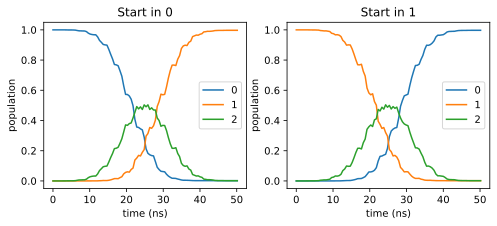

In [48]:
states = [zero, two]
expects = [x.proj() for x in states] + [one.proj()]
pops = get_pops(states, expects, props, sigma=0.1)
plot_evolution(pops, tlist);

# With Noise

In [42]:
props = get_propagator(H, tlist, 2, False, c_op_list, pulse_args, options, logi_state=[0, 1, 2], return_all_t=True)
np.log10(1-get_fidelity_super_operator(props[-1], [0, 2], qt.sigmax()))

-2.6454267641002582

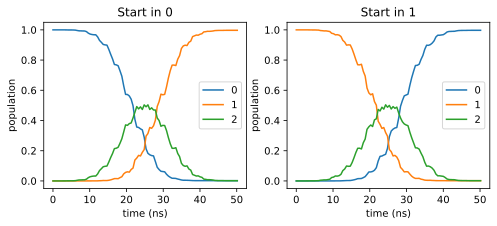

In [43]:
pops = get_pops(states, expects, props)
plot_evolution(pops, tlist);

In [44]:
args_indep = [tg, amp_A, amp_B, detune_A, detune_B]
gate_target = qt.sigmax()
args_noise = [H, w_trans_1, w_trans_2, n_cpu, c_op_list, [0, 2], False, gate_target]
xgate_fidelity_log_noise(args_indep, *args_noise)

-2.651268840008651

In [45]:
def log_infid(T1, Tphi, t, p):
    return np.log10(p*(t/(4*T1) + t/(3*Tphi)))

In [46]:
avg_pop = np.sum(pops[0, 2])*(tlist[1]-tlist[0])/tg
max_pop = np.max(pops[0, 2])
print(avg_pop, max_pop)
log_infid(T1, Tphi, tg, max_pop), log_infid(T1, Tphi, tg, avg_pop)

0.15106042607351444 0.5033036678693622


(-2.530928491296597, -3.053607881351909)

In [94]:
avg_pop = np.sum(pops[0, 2])*(tlist[1]-tlist[0])/tg
max_pop = np.max(pops[0, 2])
print(avg_pop, max_pop)
log_infid(T1, Tphi, 30, max_pop), log_infid(T1, Tphi, 30, avg_pop)

0.15106042607351444 0.5033036678693622


(-2.75410186028215, -3.276781250337462)

# Scaling Study

In [12]:
def fid_quick(T1, Tphi):
    c_op_list = []
    if T1 > 0:
        c_op_list += [np.sqrt(1/T1)*zero*one.dag()]
    if Tphi > 0:
        c_op_list += [np.sqrt(2/Tphi)*one*one.dag()]
    props = get_propagator(H, tlist, 2, False, c_op_list, pulse_args, options, logi_state=[0, 1, 2], return_all_t=True)
    return get_fidelity_super_operator(props[-1], [0, 2], qt.sigmax())

In [13]:
fid_quick(1e03, -1)

0.9953220086928186

## T1

In [14]:
from tqdm import tqdm
# t1_list = np.logspace(2, 6, 100)
t1_list = np.linspace(1e02, 1e04, 100)
t1_fid = np.zeros_like(t1_list)
for i, t1 in tqdm(enumerate(t1_list), total=len(t1_list)):
    t1_fid[i] = fid_quick(t1, -1)

100%|██████████| 100/100 [00:28<00:00,  3.56it/s]


In [15]:
# fit to rational
def func(x, a):
    return tg * a * 1 / (4 * x)
fit, cov = sp.optimize.curve_fit(func, t1_list, 1 - t1_fid)
fit

array([0.35707468])

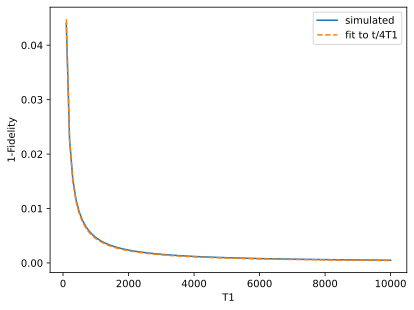

In [16]:
plt.plot(t1_list, 1-t1_fid, label="simulated")
plt.plot(t1_list, fit[0]*tg/(4*t1_list), ls="--", label="fit to t/4T1")
plt.xlabel("T1")
plt.ylabel("1-Fidelity")
plt.legend();

## $T_\phi$

In [17]:
tphi_list = np.linspace(1e02, 1e04, 100)
tphi_fid = np.zeros_like(tphi_list)
for i, tphi in tqdm(enumerate(tphi_list), total=len(tphi_list)):
    tphi_fid[i] = fid_quick(-1, tphi)

100%|██████████| 100/100 [00:27<00:00,  3.66it/s]


In [18]:
# fit to rational
def func(x, a):
    return tg * a * 1 / (3 * x)
fit, cov = sp.optimize.curve_fit(func, tphi_list, 1 - tphi_fid)
fit

array([0.36911052])

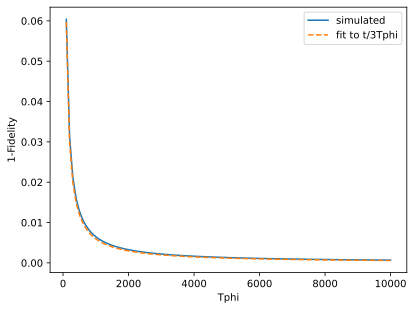

In [19]:
plt.plot(tphi_list, 1-tphi_fid, label="simulated")
plt.plot(tphi_list, fit[0]*tg/(3.1*tphi_list), ls = "--", label="fit to t/3Tphi")
plt.xlabel("Tphi")
plt.ylabel("1-Fidelity")
plt.legend();

# Optimize an X gate with max intermediate population

In [78]:
def xgate_fidelity_parallel_max_int(arg, *args):
    [H0, drive_term, w_trans_1, w_trans_2, hilbert_space, n_cpu, max_int] = args
    [tg, amp_A, amp_B, detune_A, detune_B] = arg
    pulse_args_ = {'drive_amp_A': amp_A ,
            'drive_freq_A': w_trans_1 + 2*np.pi*detune_A,
            'drive_amp_B': amp_B ,
            'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
            'gate_time': tg}
    H_qbt_drive = [H0, [drive_term,  drive_gauss_A], [drive_term,  drive_gauss_B]]
    tlist_solve = np.linspace(0, tg, 100)
    props = get_propagator(H_qbt_drive, tlist_solve, 2, False, [], pulse_args_, options, logi_state=[0, 1, 2], return_all_t=True)
    zero = qt.basis(3,0)
    one = qt.basis(3,1)
    two = qt.basis(3,2)
    states = [zero, two]
    expects = [x.proj() for x in states] + [one.proj()]
    pops = get_pops(states, expects, props)
    infid = 1-qt.average_gate_fidelity(truncate_2(props[-1], [0, 2]), qt.sigmax())
    max_pop = np.max(pops[0, 2])
    penalty = max_pop*(tg/(4*T1) + tg/(3*Tphi))
    return np.log10(infid)*(max_pop <= max_int)

In [82]:
tg_base = tlist[-1]
tg_bound = (-1, 1)
amp1_bounds = (0, 0.3)
amp2_bounds = (0, 0.3)
detune1_bounds = (-0.3, 0.3)
detune2_bounds = (-0.3, 0.3)
tg_bounds = (tg_base + tg_bound[0], tg_base + tg_bound[1])
bounds = (tg_bounds, amp1_bounds, amp2_bounds, detune1_bounds, detune2_bounds)

args_max = args + [0.10]

# Optimize fidelity using differential evolution
res_max = sp.optimize.differential_evolution(
    func=xgate_fidelity_parallel_max_int,
    bounds=bounds,
    args=args_max,
    disp=True,
    callback=print_soln,
    init="sobol",
    workers=workers,
    popsize=popsize,
    mutation=mutation,
    recombination=recombination,
    tol=tol,
    polish=False,
    maxiter=1000,
    x0=res_max.x
)

 /home/eweissler/anaconda3/envs/enum/lib/python3.11/site-packages/scipy/optimize/_differentialevolution.py: 387

differential_evolution step 1: f(x)= -0.341218
Best Solution: [49.27012744, 0.06900068, 0.13232129, -0.25027658, -0.27928038]
Convergence: 0.0105
----------------------------
differential_evolution step 2: f(x)= -0.341218
Best Solution: [49.27012744, 0.06900068, 0.13232129, -0.25027658, -0.27928038]
Convergence: 0.0152
----------------------------
differential_evolution step 3: f(x)= -0.341218
Best Solution: [49.27012744, 0.06900068, 0.13232129, -0.25027658, -0.27928038]
Convergence: 0.0202
----------------------------
differential_evolution step 4: f(x)= -0.341218
Best Solution: [49.27012744, 0.06900068, 0.13232129, -0.25027658, -0.27928038]
Convergence: 0.0245
----------------------------
differential_evolution step 5: f(x)= -0.498844
Best Solution: [50.5979799, 0.08586473, 0.10066286, -0.12523214, -0.14506516]
Convergence: 0.0271
----------------------------
differential_evolution step 6: f(x)= -0.580773
Best Solution: [51.08252584, 0.04640495, 0.10221908, -0.07989503, -0.07058876]


Fidelity: -3.1343142432497437


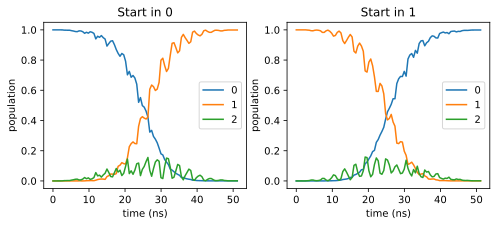

In [84]:
plot_res(res_max, w_trans_1, w_trans_2, H0, H1, c_op_list)

In [87]:
tg_base = tlist[-1]
tg_bound = (-1, 1)
amp1_bounds = (0, 0.3)
amp2_bounds = (0, 0.3)
detune1_bounds = (-0.3, 0.3)
detune2_bounds = (-0.5, 0.5)
tg_bounds = (tg_base + tg_bound[0], tg_base + tg_bound[1])
bounds = (tg_bounds, amp1_bounds, amp2_bounds, detune1_bounds, detune2_bounds)

args_max = args + [0.15]

# Optimize fidelity using differential evolution
res_max = sp.optimize.differential_evolution(
    func=xgate_fidelity_parallel_max_int,
    bounds=bounds,
    args=args_max,
    disp=True,
    callback=print_soln,
    init="sobol",
    workers=workers,
    popsize=popsize,
    mutation=mutation,
    recombination=recombination,
    tol=tol,
    polish=False,
    maxiter=1000,
    x0=res_max.x
)

 /home/eweissler/anaconda3/envs/enum/lib/python3.11/site-packages/scipy/optimize/_differentialevolution.py: 387

differential_evolution step 1: f(x)= -1.43578
Best Solution: [49.69178988, 0.06465738, 0.08652452, -0.12709805, -0.13094844]
Convergence: 0.0047
----------------------------
differential_evolution step 2: f(x)= -1.43578
Best Solution: [49.69178988, 0.06465738, 0.08652452, -0.12709805, -0.13094844]
Convergence: 0.0068
----------------------------
differential_evolution step 3: f(x)= -1.43578
Best Solution: [49.69178988, 0.06465738, 0.08652452, -0.12709805, -0.13094844]
Convergence: 0.0081
----------------------------
differential_evolution step 4: f(x)= -1.43578
Best Solution: [49.69178988, 0.06465738, 0.08652452, -0.12709805, -0.13094844]
Convergence: 0.0095
----------------------------
differential_evolution step 5: f(x)= -1.43578
Best Solution: [49.69178988, 0.06465738, 0.08652452, -0.12709805, -0.13094844]
Convergence: 0.0114
----------------------------
differential_evolution step 6: f(x)= -1.43578
Best Solution: [49.69178988, 0.06465738, 0.08652452, -0.12709805, -0.13094844]
Conve

Fidelity: -3.112878216076177


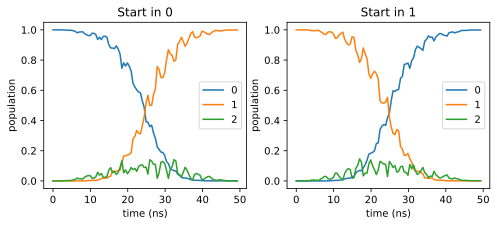

In [88]:
plot_res(res_max, w_trans_1, w_trans_2, H0, H1, c_op_list)

# Optimize an X gate with noise estimate

In [76]:
def xgate_fidelity_parallel_penalty(arg, *args):
    [H0, drive_term, w_trans_1, w_trans_2, hilbert_space, n_cpu] = args
    [tg, amp_A, amp_B, detune_A, detune_B] = arg
    pulse_args_ = {'drive_amp_A': amp_A ,
            'drive_freq_A': w_trans_1 + 2*np.pi*detune_A,
            'drive_amp_B': amp_B ,
            'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
            'gate_time': tg}
    H_qbt_drive = [H0, [drive_term,  drive_gauss_A], [drive_term,  drive_gauss_B]]
    tlist_solve = np.linspace(0, tg, 100)
    props = get_propagator(H_qbt_drive, tlist_solve, 2, False, [], pulse_args_, options, logi_state=[0, 1, 2], return_all_t=True)
    zero = qt.basis(3,0)
    one = qt.basis(3,1)
    two = qt.basis(3,2)
    states = [zero, two]
    expects = [x.proj() for x in states] + [one.proj()]
    pops = get_pops(states, expects, props)
    infid = 1-qt.average_gate_fidelity(truncate_2(props[-1], [0, 2]), qt.sigmax())
    max_pop = np.max(pops[0, 2])
    penalty = max_pop*(tg/(4*T1) + tg/(3*Tphi))
    return np.log10(infid + penalty)

In [77]:
tg_base = tlist[-1]
tg_bound = (-1, 1)
amp1_bounds = (0, 0.3)
amp2_bounds = (0, 0.3)
detune1_bounds = (-0.3, 0.3)
detune2_bounds = (-0.3, 0.3)
tg_bounds = (tg_base + tg_bound[0], tg_base + tg_bound[1])
bounds = (tg_bounds, amp1_bounds, amp2_bounds, detune1_bounds, detune2_bounds)

# Optimize fidelity using differential evolution
res_est = sp.optimize.differential_evolution(
    func=xgate_fidelity_parallel_penalty,
    bounds=bounds,
    args=args,
    disp=True,
    callback=print_soln,
    init="sobol",
    workers=workers,
    popsize=popsize,
    mutation=mutation,
    recombination=recombination,
    tol=tol,
    polish=False,
    maxiter=1000,
    x0=res.x
)

differential_evolution step 1: f(x)= -2.53007
Best Solution: [50.15273525, 0.02594967, 0.025934, 0.00079082, 7.52e-05]
Convergence: 0.0128
----------------------------
differential_evolution step 2: f(x)= -2.53007
Best Solution: [50.15273525, 0.02594967, 0.025934, 0.00079082, 7.52e-05]
Convergence: 0.0132
----------------------------
differential_evolution step 3: f(x)= -2.53007
Best Solution: [50.15273525, 0.02594967, 0.025934, 0.00079082, 7.52e-05]
Convergence: 0.0132
----------------------------
differential_evolution step 4: f(x)= -2.53007
Best Solution: [50.15273525, 0.02594967, 0.025934, 0.00079082, 7.52e-05]
Convergence: 0.0133
----------------------------
differential_evolution step 5: f(x)= -2.53007
Best Solution: [50.15273525, 0.02594967, 0.025934, 0.00079082, 7.52e-05]
Convergence: 0.0136
----------------------------
differential_evolution step 6: f(x)= -2.53007
Best Solution: [50.15273525, 0.02594967, 0.025934, 0.00079082, 7.52e-05]
Convergence: 0.0136
---------------------

Fidelity: -3.112547731027931


 /tmp/ipykernel_3645730/2615538469.py: 12

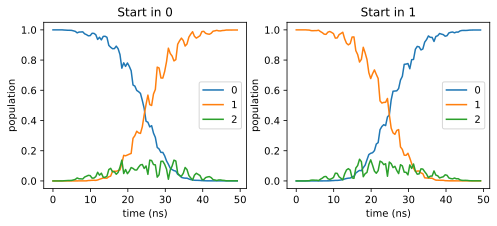

In [80]:
plot_res(res_est, w_trans_1, w_trans_2, H0, H1, c_op_list)

# Optimize an X gate with Noise

In [83]:
def xgate_fidelity_noise_fast(arg, *args):
    [H_qbt_drive, w_trans_1, w_trans_2, n_cpu, c_op_list, logi_state, parallel, gate_target]  = args
    [tg, amp_A, amp_B, detune_A, detune_B] = arg
    pulse_args_ = {'drive_amp_A': amp_A ,
            'drive_freq_A': w_trans_1 + 2*np.pi*detune_A,
            'drive_amp_B': amp_B ,
            'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
            'gate_time': tg}
    tlist_solve = np.linspace(0, tg, 100)
    props = get_propagator(H_qbt_drive, tlist_solve, 2, False, c_op_list, pulse_args_, options, logi_state=[0, 1, 2], return_all_t=True)
    return np.log10(1-get_fidelity_super_operator(props[-1], [0, 2], qt.sigmax()))

In [90]:
tg_base = tlist[-1]
tg_bound = (-1, 1)
amp1_bounds = (0, 0.3)
amp2_bounds = (0, 0.3)
detune1_bounds = (-0.3, 0.3)
detune2_bounds = (-0.3, 0.3)
tg_bounds = (tg_base + tg_bound[0], tg_base + tg_bound[1])
bounds = (tg_bounds, amp1_bounds, amp2_bounds, detune1_bounds, detune2_bounds)

# Optimize fidelity using differential evolution
res_noise = sp.optimize.differential_evolution(
    func=xgate_fidelity_noise_fast,
    bounds=bounds,
    args=args_noise,
    disp=True,
    callback=print_soln,
    init="sobol",
    workers=workers,
    popsize=popsize,
    mutation=mutation,
    recombination=recombination,
    tol=tol,
    polish=False,
    maxiter=1000,
    x0=res.x
)

 /home/eweissler/anaconda3/envs/enum/lib/python3.11/site-packages/scipy/optimize/_differentialevolution.py: 387

differential_evolution step 1: f(x)= -2.64543
Best Solution: [50.15273525, 0.02594967, 0.025934, 0.00079082, 7.52e-05]
Convergence: 0.0123
----------------------------
differential_evolution step 2: f(x)= -2.64543
Best Solution: [50.15273525, 0.02594967, 0.025934, 0.00079082, 7.52e-05]
Convergence: 0.0126
----------------------------
differential_evolution step 3: f(x)= -2.64543
Best Solution: [50.15273525, 0.02594967, 0.025934, 0.00079082, 7.52e-05]
Convergence: 0.0125
----------------------------
differential_evolution step 4: f(x)= -2.64543
Best Solution: [50.15273525, 0.02594967, 0.025934, 0.00079082, 7.52e-05]
Convergence: 0.0129
----------------------------
differential_evolution step 5: f(x)= -2.64543
Best Solution: [50.15273525, 0.02594967, 0.025934, 0.00079082, 7.52e-05]
Convergence: 0.0129
----------------------------
differential_evolution step 6: f(x)= -2.64543
Best Solution: [50.15273525, 0.02594967, 0.025934, 0.00079082, 7.52e-05]
Convergence: 0.013
----------------------

Fidelity: -3.15691162594157


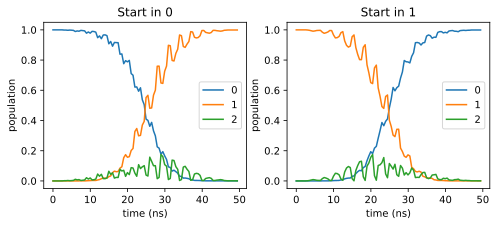

In [91]:
plot_res(res_noise, w_trans_1, w_trans_2, H0, H1, c_op_list)

-0.176091527744275


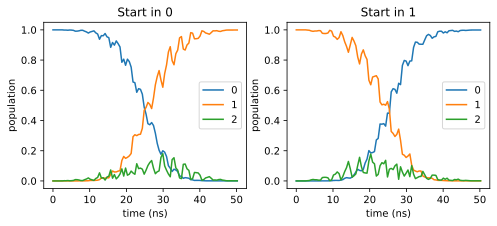

In [17]:
tg, amp_A, amp_B, detune_A, detune_B = res2.x
pulse_args = {'drive_amp_A': amp_A ,
            'drive_freq_A': w_trans_1 + 2*np.pi*detune_A,
            'drive_amp_B': amp_B ,
            'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
            'gate_time': tg}

H = [H0, [H1,  drive_gauss_A], [H1,  drive_gauss_B]]

tlist = np.linspace(0, tg, 100)

options = qt.Options()

props = get_propagator(H, tlist, 2, False, c_op_list, pulse_args, options, logi_state=[0, 1, 2], return_all_t=True)
print(np.log10(1-qt.average_gate_fidelity(truncate_2(props[-1], [0, 2]), qt.sigmax())))

states = [zero, two]
expects = [x.proj() for x in states] + [one.proj()]
pops = get_pops(states, expects, props)
plot_evolution(pops, tlist);